In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
 df = pd.read_csv("compressed_data.csv")

C:\Users\singh\AppData\Local\Temp\ipykernel_166052\3043745453.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("compressed_data.csv")


In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

First,Let's Check the Missing Values !

In [5]:
#It give us the missing values from our dataset !
print(df.isnull().sum())

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
#Lets see which column have which type of data !
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

#If you notice LastReveiw is object , but inside that column we have data , So we have to work on it ! by converting into date/time format !

In [7]:
#Coerce ->means if a value cannot be coverted into a valid date,replace it with NaT !
df['last review'] = pd.to_datetime(df['last review'],errors ='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102349 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102193 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

1)-In Review per month ,Lot of value missing and it is imp column so we have to deal with that(Replace ->NAN to 0)meaning same 0 aso represent no value !

2)-In 'last review' >There are some date missing so we replace that with last date (Means->It's like review of room/service,so when last time any person rate this we enter that date , in this missing one !)

In [9]:
#fillna ->Used to fill missing (empty)values in the dataset !
#.min()->Means fill it with earliest date from Last review month 
#inplace ->Permanent changes !
df.fillna({'reviews per month' :0 , 'last review':df['last review'].min()},inplace = True)

1)- We handle the Name and Host Name missing value also, by drop it from table !

In [10]:
#dropna->Function is used to remove the row , that contain the missing value !
#subset ->means telling the Python, Check only these two columns - NAME and host name
df.dropna(subset =['NAME','host name'],inplace = True)

In [11]:
#Now Let's Check how many missing values, we handle/Remove !
print(df.isnull().sum())
#Focus on NAME,host name,last review and reviews per month (All are Zero !)

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

1)-Like in this dataset ,I dont need the house_rules and license,so let's remove it !

In [12]:
#errors ='ignore'->Means ,If this column does not exist ,Python not give error they simple Ignore it !
df = df.drop(columns=["license","house_rules"],errors='ignore')

1)Now in "Service fee" Column there is symbol of dollar ! ,So we remove this to handle with the data

2)Also we change the daya type of "Servcie free" and "Price" column from object to floating point !

In [13]:
#replace -> " $ " with ' '<-empty ! , and change type (astype) from object->float !
#regex ->True,Means that thing should be performed !

df['price'] = df['price'].replace('[\$,]','',regex = True).astype(float)
df['service fee'] =df['service fee'].replace('[\$]','',regex=True).astype(float)

<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\singh\AppData\Local\Temp\ipykernel_166052\3354903201.py:4: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['price'] = df['price'].replace('[\$,]','',regex = True).astype(float)
C:\Users\singh\AppData\Local\Temp\ipykernel_166052\3354903201.py:5: SyntaxWarning: "\$" is an inva

If any duplicate value exist then we remove it !

In [14]:
df.drop_duplicates(inplace = True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

# Visualization

# Q1->What is the distribution of listening prices ?

In [16]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,101410,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2018-05-15 21:26:08.721033728,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-30 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


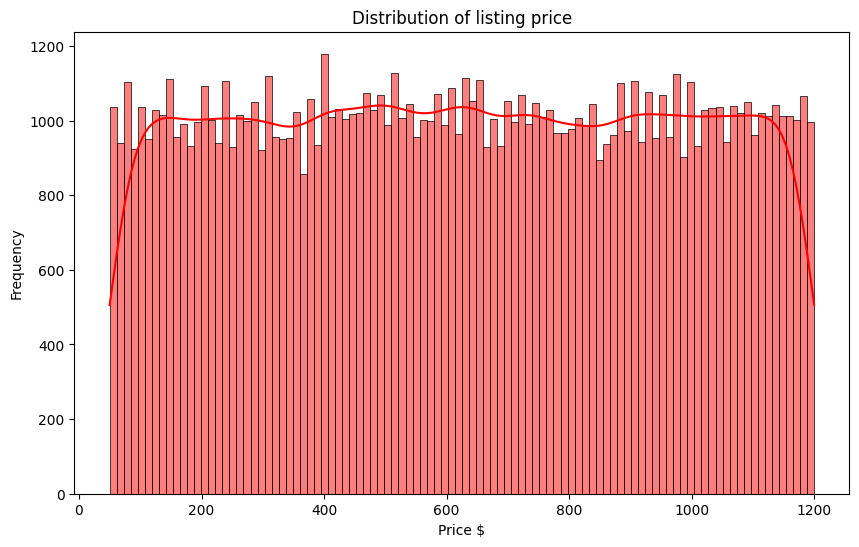

In [17]:
plt.figure(figsize = (10,6))
#sns ->seaborn library !
#bins -> means how many groups to divide the data info ! (More Bins -> More Detailed graph)
#kde(Kernel Density Estimate) ->It adds a Smooth Curve line over the histogram  (It over the )
sns.histplot(df['price'], bins =100,kde = True, color = 'red')

plt.title("Distribution of listing price")
plt.xlabel("Price $")
plt.ylabel("Frequency")
plt.show()

#x axis -> price of listing(is house or room or apartment), in y-axix hwo many listing exist in that particular range
                                                                #(like 200(x axis price), so,over 1000 listing exist)

The histogram shows a fairly even distribution of 
listing prices across different price ranges, indicating no
particular concentration of listings in any specific price range.
The KDE line helps visualize this even spread more clearly,
confirming that the dataset contains listings with a wide variety of prices 

# Q2-> How are different room types distributed ?

In [18]:
df.columns
#So,Here is the "room type" column we use this find the answer of this question !

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365'],
      dtype='object')

In [19]:
df['room type']

0            Private room
1         Entire home/apt
2            Private room
4         Entire home/apt
5         Entire home/apt
               ...       
102053       Private room
102054       Private room
102055    Entire home/apt
102056       Private room
102057    Entire home/apt
Name: room type, Length: 101410, dtype: object

So,Which Room pleople liked most , we make the graph for it 

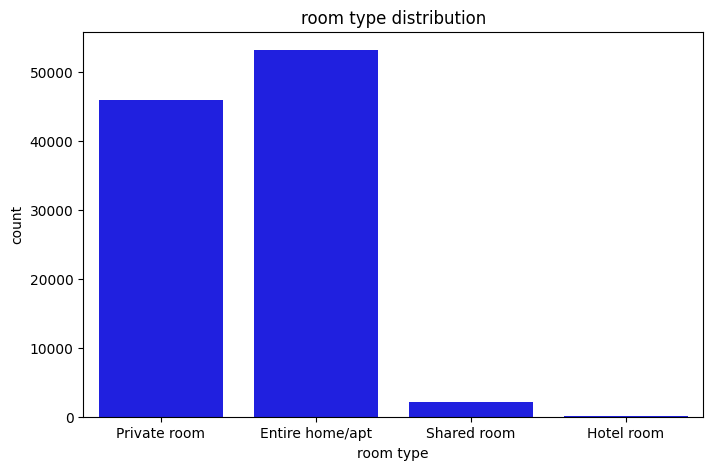

In [20]:
plt.figure(figsize = (8,5))
sns.countplot(x = "room type",data =df,color = "blue")
plt.title("room type distribution")
plt.xlabel("room type")
plt.ylabel("count")
plt.show()

So, Many people like to purchase Entire home/apt from air bnb , and then most people book the private room and others Shared room ,Hotel room etc from air bnb

# Q3-> How are listings distributed across different neighborhoods ?

In [21]:
df.head(2)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0


#So we make the graph and show the differetn neighborhoods

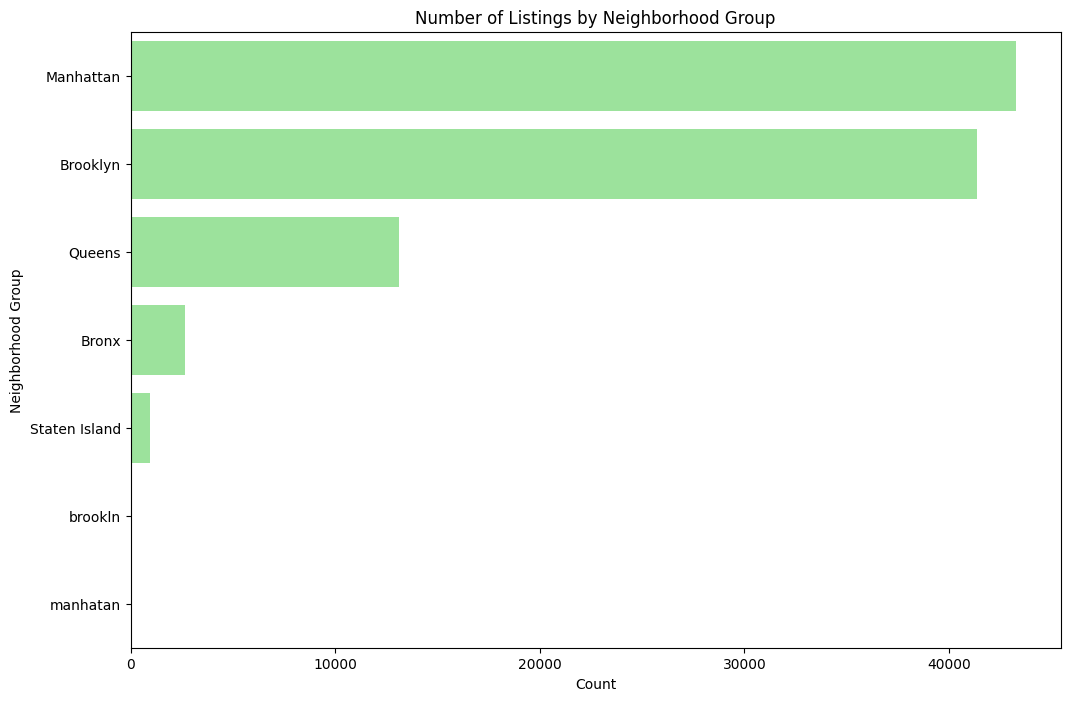

In [22]:
plt.figure(figsize = (12,8))
sns.countplot(y='neighbourhood group',data = df,color ="lightgreen",order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.xlabel('Count')
plt.ylabel('Neighborhood Group')
plt.show()

#SO ,we get there are more listings(property) available in Manhattan (It does mean that people all book !, it show the availability in that area)

So,This graph shows that Manhattan has the highest number of listings,followed by Brooklyn,Queens,Bronx and Staten Island etc.This means more Airbnb properties are located in Manhattan !

# Q4-> WHAT IS THE RELATIONSHIP BETWEEN PRICE AND ROOM TYPE ?

C:\Users\singh\AppData\Local\Temp\ipykernel_166052\967534368.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Room Type')


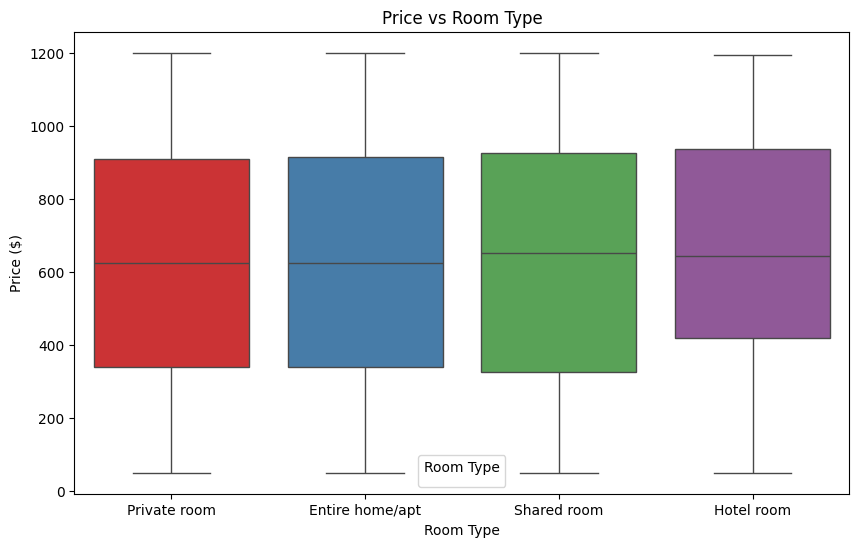

In [23]:
#So we use here Boxplot to solve this !
plt.figure(figsize=(10,6))
sns.boxplot(x='room type',y='price',hue='room type',data=df,palette='Set1')
plt.title('Price vs Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.legend(title='Room Type')
plt.show()

The boxplot shows that price varies depending on the room type. Private rooms, entire homes/apartments, and shared rooms have somewhat similar price distributions with small variations between them. However, hotel rooms generally appear more expensive compared to the other room types. This suggests that the type of room and the level of space or privacy can influence the listing price.

# Q5-> How as the number of Reviews change over with time ?

In [24]:
df.head(2)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0


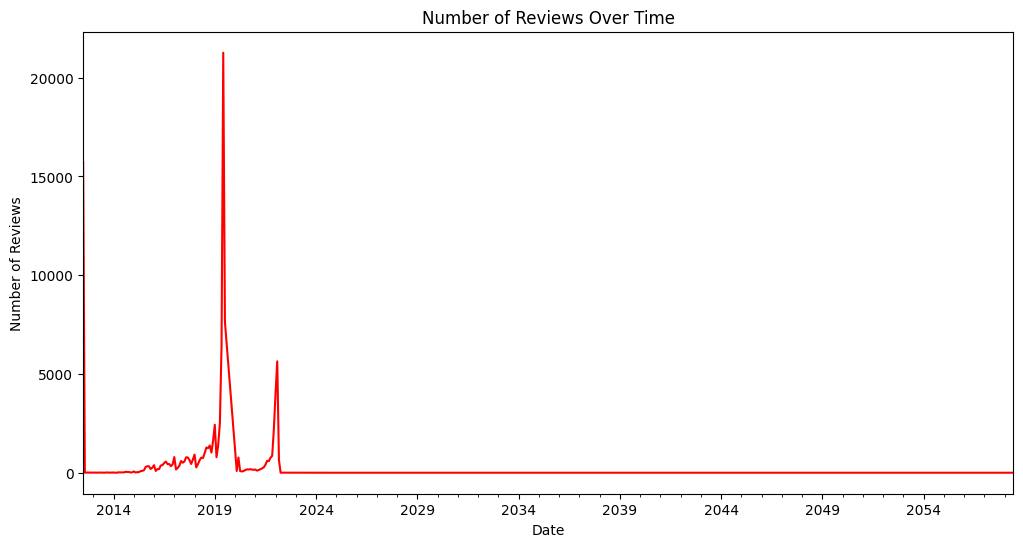

In [25]:
#First,Covert into dateTime format !
df['last review'] = pd.to_datetime(df['last review']) 
#Doing groupby by (Month)acc data , we want to see !
#Like it in every month , total review add it and give(like jan-200 review,Feb-250 review)etc !
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

#Set the size of graph,Plot Line Graph
plt.figure(figsize=(12,6))
reviews_over_time.plot(kind='line',color='red')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

The line graph shows that the number of reviews increases over time and reaches its peak around 2019 to 2020. This indicates that Airbnb activity was highest during this period, with more users booking listings and leaving reviews. The increasing trend suggests growing popularity and usage of the platform during these years.

# Q6-> Top 10 most Expensive Listings ?

In [26]:
df.head(5)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,2005.0,620.0,124.0,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,2013.0,577.0,115.0,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0


In [27]:
top10 = df.sort_values(by='price',ascending=False).head(10)

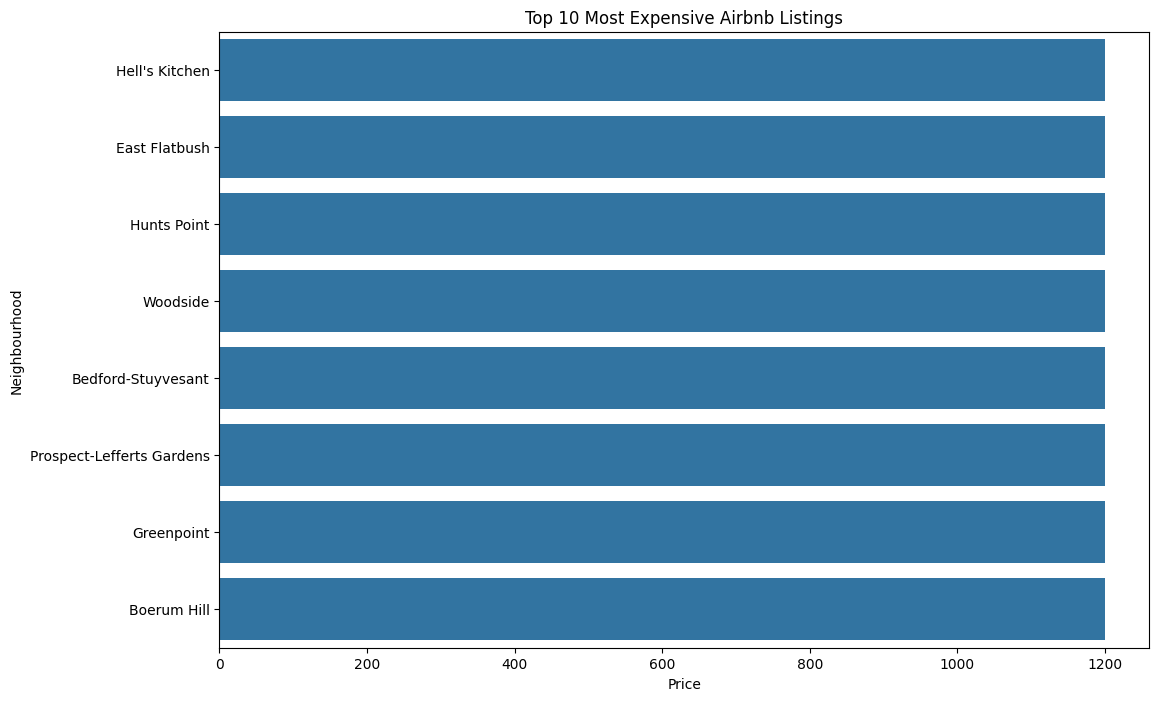

In [28]:
plt.figure(figsize =(12,8))
sns.barplot(x='price',y='neighbourhood',data=top10)
plt.title('Top 10 Most Expensive Airbnb Listings')
plt.xlabel('Price')
plt.ylabel('Neighbourhood')
plt.show()

The analysis shows that Hell's Kitchen has the most expensive Airbnb listings. After that, East Flatbush, Hunts Point, and Woodside also have high-priced listings. This indicates that these areas contain some of the most expensive Airbnb properties.

# Q7-> Which Neighborhood Has the Highest Average Listing Price ?

In [29]:
avg_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending =False).head(10)

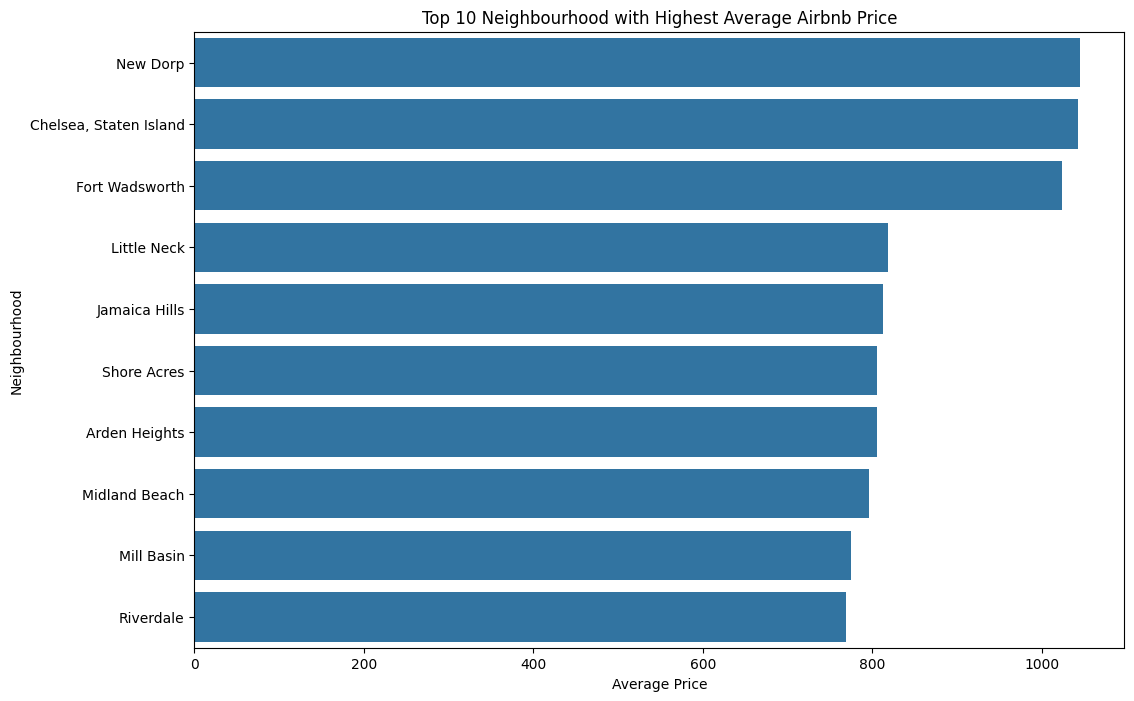

In [30]:
plt.figure(figsize=(12,8))
sns.barplot(x=avg_price.values,y=avg_price.index)
plt.title('Top 10 Neighbourhood with Highest Average Airbnb Price')
plt.xlabel('Average Price')
plt.ylabel('Neighbourhood')
plt.show()

The analysis shows that New Dorp has the highest average Airbnb price. After that, Chelsea and Staten Island have almost the same average price. Fort Wadsworth and Little Neck also have relatively high prices. This indicates that these neighbourhoods have more expensive Airbnb listings compared to other areas.

# Q8->Which room type appears most frequently in Airbnb listings ?

In [31]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365'],
      dtype='object')

In [32]:
Room_common = df['room type'].value_counts().sort_values(ascending=False)

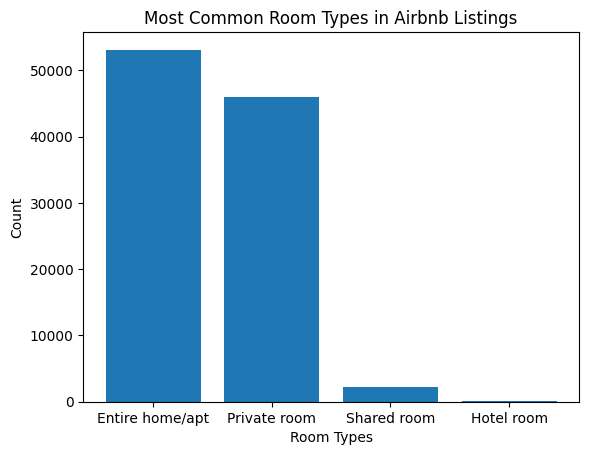

In [33]:
plt.bar(Room_common.index, Room_common.values)
plt.xlabel("Room Types")
plt.ylabel("Count")
plt.title("Most Common Room Types in Airbnb Listings")
plt.show()

The analysis shows that Entire home/apt listings are the most common on Airbnb. Private rooms are the second most common. There is a very large gap between these two and shared rooms or hotel rooms, which appear much less frequently. This suggests that most hosts prefer listing entire homes or private rooms.

# Q9-> Which Neighbourhood has the Most Reviews ?

In [34]:
reviews = df.groupby('neighbourhood')['number of reviews'].sum().sort_values(ascending=False).head(10)

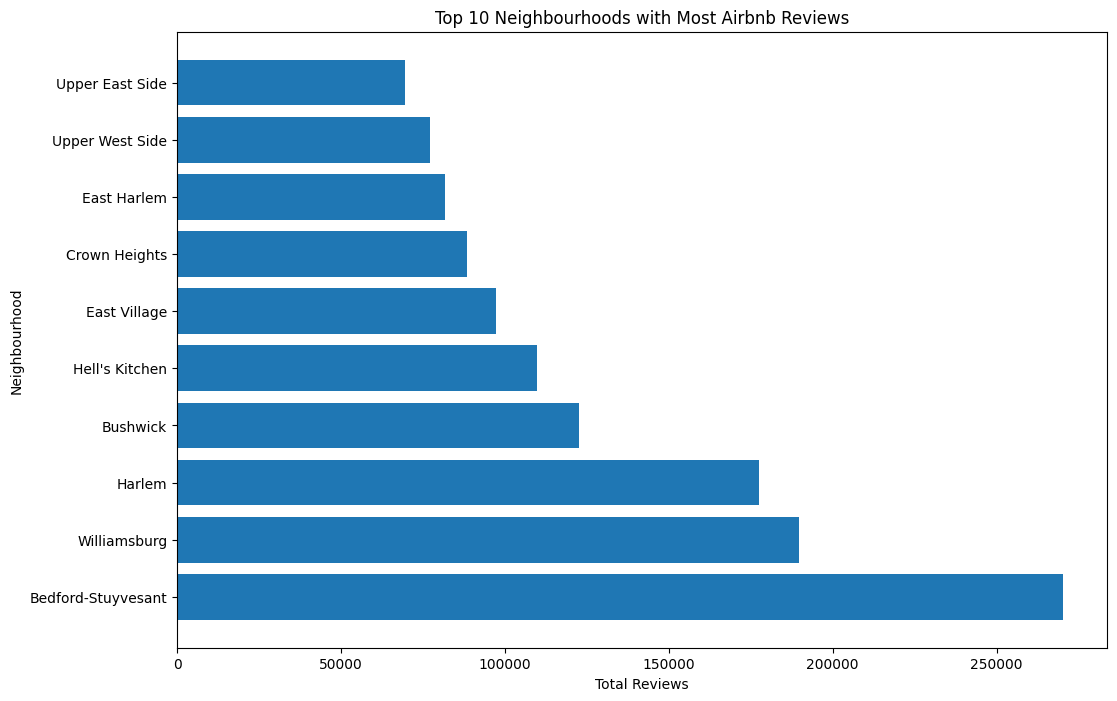

In [35]:
plt.figure(figsize=(12,8))
plt.barh(reviews.index, reviews.values)

plt.xlabel("Total Reviews")
plt.ylabel("Neighbourhood")
plt.title("Top 10 Neighbourhoods with Most Airbnb Reviews")

plt.show()

The analysis shows that some neighbourhoods have a higher number of Airbnb reviews than others. This means these areas are more popular among guests and receive more bookings. Neighbourhoods with the most reviews are likely popular tourist locations.

# Q10-> Which Hosts have the most listings ?

In [36]:
df.head(2)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0


In [37]:
host = df['host name'].value_counts().head(10)

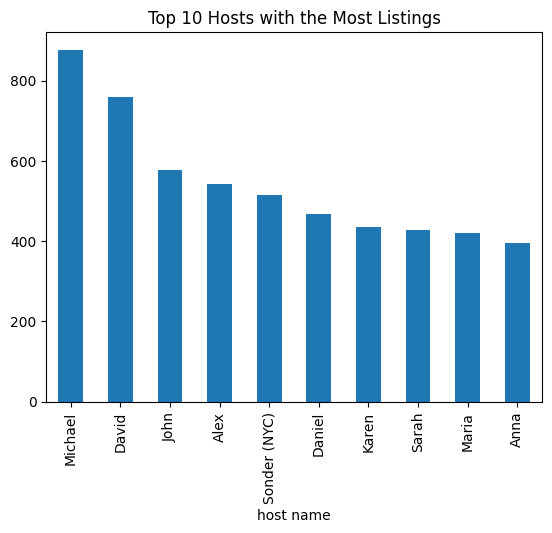

In [38]:
host.plot(kind="bar")
plt.title("Top 10 Hosts with the Most Listings")
plt.show()

In this analysis, we can see that Michael has the highest number of listings compared to other hosts. After Michael, David and John also have a high number of listings. This indicates that some hosts manage multiple Airbnb properties.

# Q11->Which listings have the highest number of reviews ?

In [39]:
df.head(1)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0


In [40]:
highest_rev = df.groupby("neighbourhood group")["price"].mean().sort_values(ascending=False).reset_index()
#we use reset.index(),bec seaborn when x,y mean they look two column but neighbourhood <- is act as index in highest_rev,so that why 
#we reset their index !

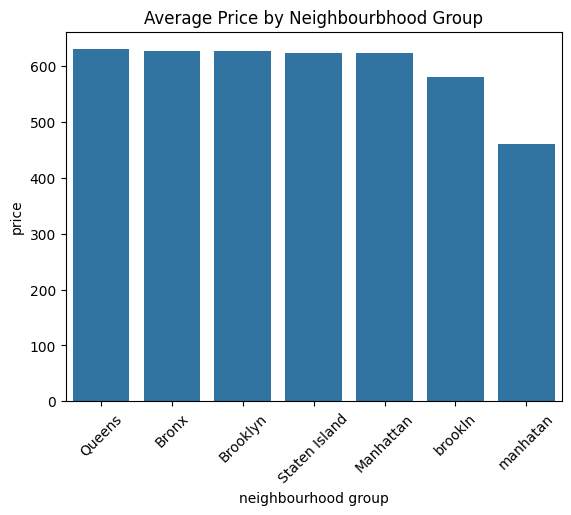

In [41]:
sns.barplot(x="neighbourhood group",y="price",data=highest_rev)
plt.title("Average Price by Neighbourbhood Group")
plt.xticks(rotation=45) #So our name not collide !
plt.show()

# Q12->Which neighbourhood group has highest Availbility ?

In [42]:
df.head(1)    #check !!!!!!!! <- it not run 

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0


In [43]:
negh_available = df.groupby("neighbourhood group")["availability 365"].mean().reset_index()

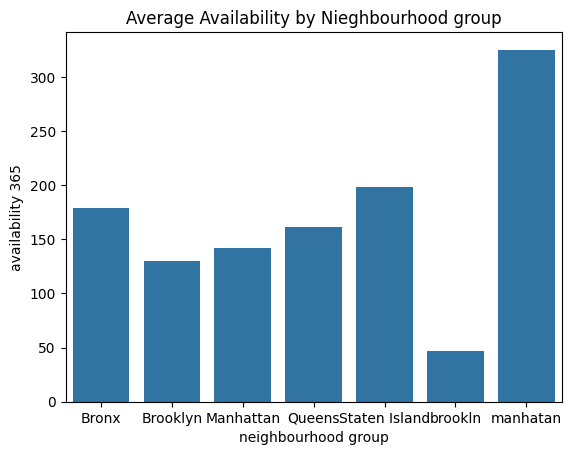

In [44]:
sns.barplot(x="neighbourhood group",y="availability 365",data=negh_available)
plt.title("Average Availability by Nieghbourhood group")
plt.show()

his graph shows the average number of days Airbnb listings are available in different neighbourhood groups. Manhattan has the highest availability, followed by Staten Island and Bronx, while Brooklyn and Queens have lower availability, indicating potentially higher booking demand in those areas. 

# Q13->Which room type is most common and most expensive ?

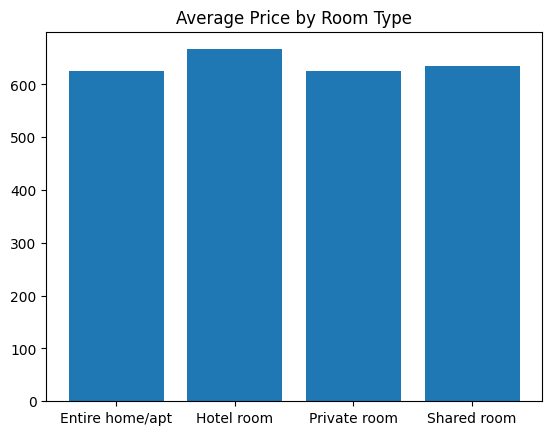

In [64]:
room_price= df.groupby('room type')['price'].mean()

plt.bar(room_price.index,room_price.values)
plt.title("Average Price by Room Type")
plt.show()

The bar chart shows the average price of Airbnb listings by room type. The results indicate that hotel rooms have the highest average price, while entire homes, private rooms, and shared rooms have similar average prices. This suggests that hotel-style accommodations tend to be slightly more expensive compared to other room types.

# Q14->Does Availability affect Price ?

In [65]:
df.head(2)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0


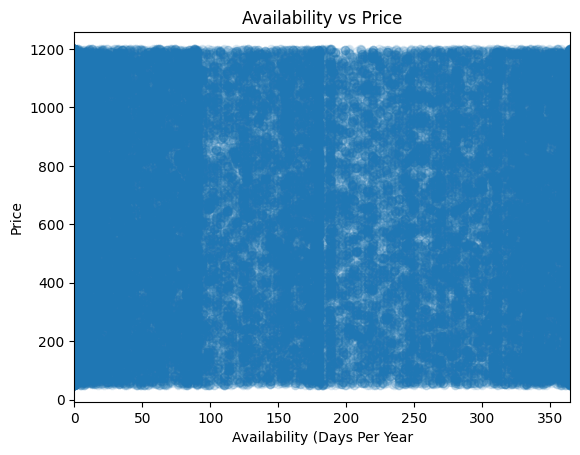

In [79]:
plt.scatter(df["availability 365"],df["price"],alpha=0.1)
plt.xlim(0,365)
plt.xlabel("Availability (Days Per Year")
plt.ylabel("Price")
plt.title("Availability vs Price")
plt.show()

#x axix-> Availabilty show(0 to365),y axis ->(Price)and Each dot->One Airbus 

The scatter plot compares listing availability with price. The data points are widely distributed across all availability levels, and no clear pattern is observed. This suggests that availability does not significantly affect listing price, and other factors such as location, room type, or amenities may play a more important role in determining price.

# Q15->Do highly reviewed listings have better availability ?

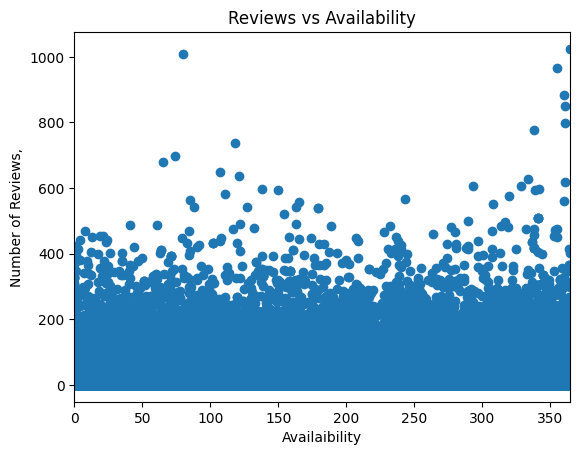

In [83]:
plt.scatter(df["availability 365"],df["number of reviews"])
plt.xlim(0,365)
plt.xlabel("Availaibility")
plt.ylabel("Number of Reviews,")
plt.title("Reviews vs Availability")
plt.show()

The scatter plot shows the relationship between the number of reviews and listing availability. Most listings have reviews between 0 and 400 and are available across the full range of 0 to 365 days. However, some listings with a high number of reviews tend to have lower availability, suggesting that highly reviewed listings may be booked more frequently.


# Q16->Price Distribution of Airbnb listings ?

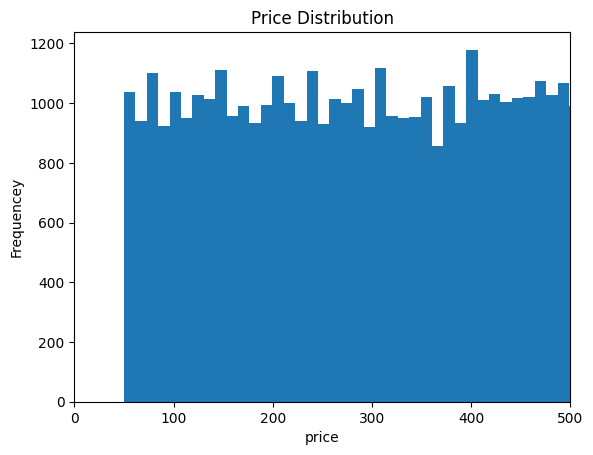

In [84]:
plt.hist(df["price"],bins =100)
plt.xlim(0,500)
plt.title("Price Distribution")
plt.xlabel("price")
plt.ylabel("Frequencey") #no of listing !
plt.show()

#price liek 50 to 500 dollar !
#mostly range-> from 900 to 1000 lisitng !

The histogram shows the distribution of Airbnb listing prices. Most listings fall within the price range of approximately $50  to $500. The frequency of listings across different price ranges is relatively similar, indicating that Airbnb offers properties at various price levels to accommodate different budgets.